In [3]:
import pandas as pd
import matplotlib.pyplot as plt

stock_df = pd.read_csv('output/data/raw_data.csv', index_col='timestamp', parse_dates=True)

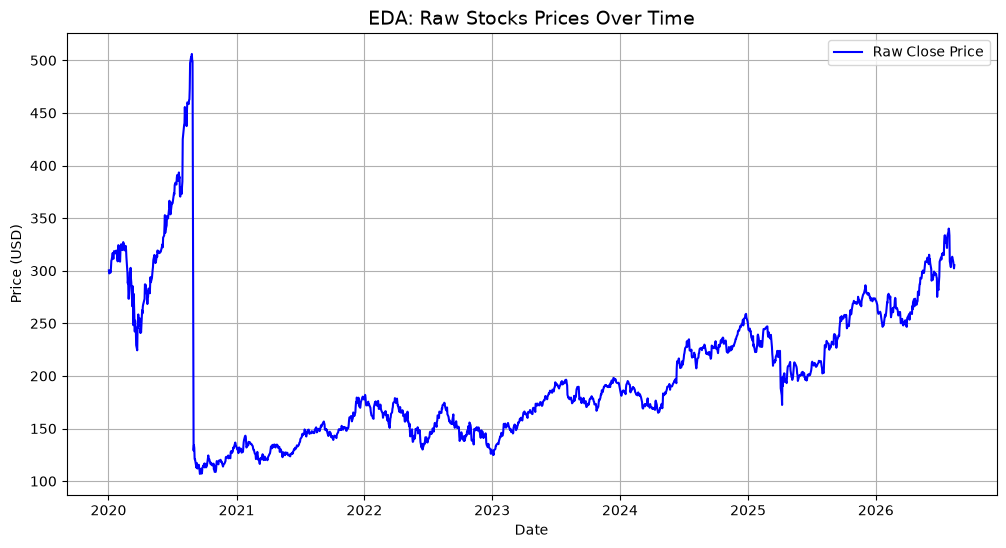

In [4]:
plt.figure(figsize=(12, 6))

# Plot the raw closing prices
plt.plot(stock_df.index, stock_df['close'], label='Raw Close Price', color='blue')

# Add labels and title to make it readable
plt.title('EDA: Raw Stocks Prices Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

plt.show()

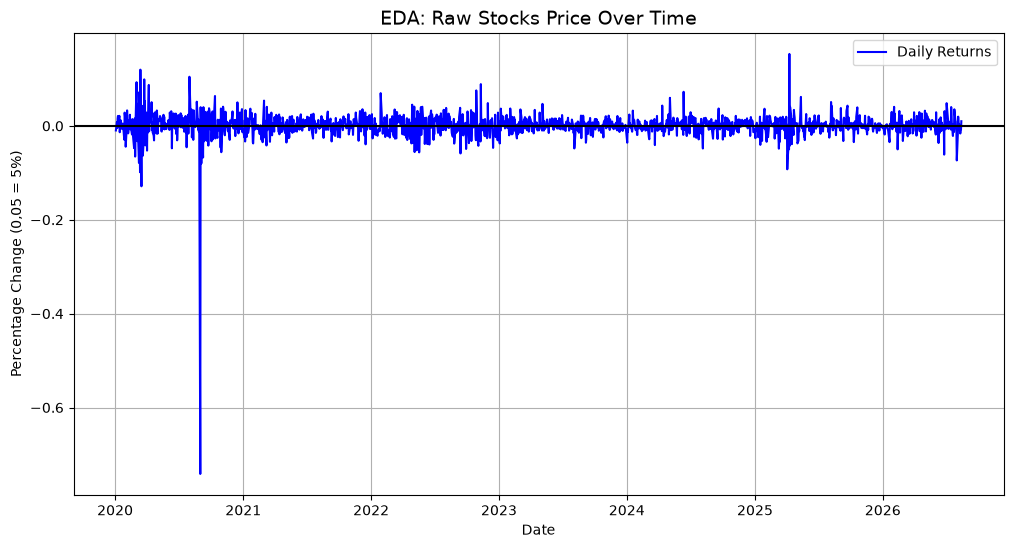

In [5]:
# This automatically calculates: (Today - Yesterday) / Yesterday
stock_df['daily return'] = stock_df['close'].pct_change()

# Drop Missing Data
stock_df = stock_df.dropna()

plt.figure(figsize=(12, 6))

# Plot Daily Returns
plt.plot(stock_df.index, stock_df['daily return'], label='Daily Returns', color='blue')

# Add Baseline
plt.axhline(0, color='black')

# Add labels and title
plt.title('EDA: Raw Stocks Price Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Percentage Change (0,05 = 5%)')
plt.legend()
plt.grid(True)

plt.show()

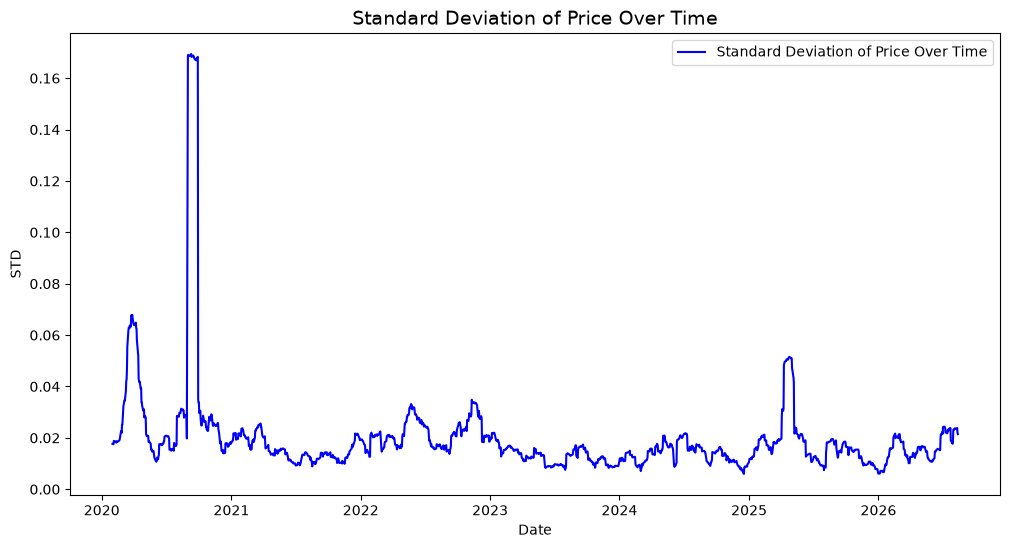

In [6]:
# We would like to count Risk Metric
# For that we use Standard Deviation because we'd like to calculate the unpredictability

# Standard Deviation measures exactly how far, on average, the daily returns stray away from that zero baseline
# Higher SD means Highly Volatile, Lower SD means Highly Predictable
plt.figure(figsize=(12, 6))

# Plot Standard Deviation
plt.plot(stock_df.index, stock_df['daily return'].rolling(window=20).std(), label='Standard Deviation of Price Over Time', color='blue')

plt.title('Standard Deviation of Price Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('STD')
plt.legend()
plt.show()

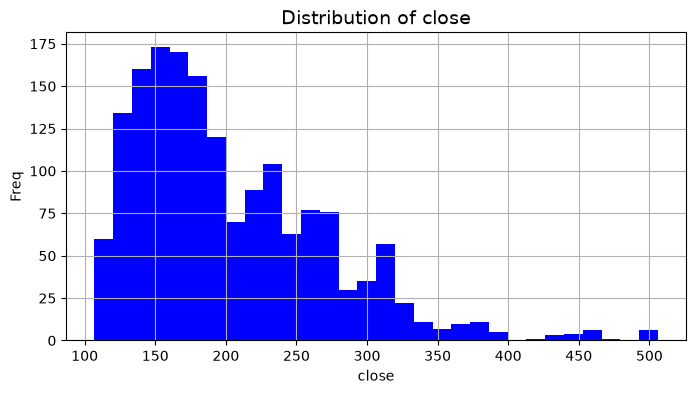

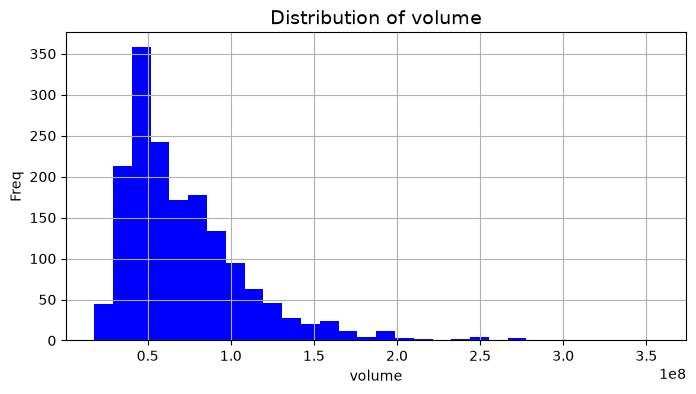

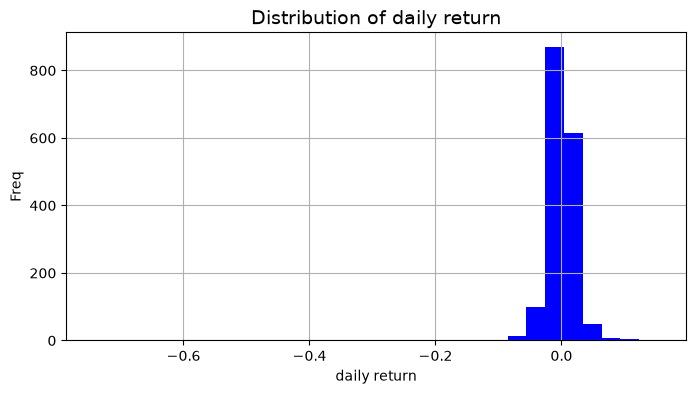

In [7]:
# Calculate Feature Distribution
# Left-Skewed(Negative) means it freq has small and steady winning. But when it loses, it crashes violently
# Right-Skewed(Positive) means that the stock has small loses. But when it wins, it spikes drastically
feature = ['close', 'volume', 'daily return']

# For loop to iterate every column/feature
for f in feature:
    plt.figure(figsize=(8, 4))

    plt.hist(stock_df[f].dropna(), bins = 30, color='blue')

    plt.title(f'Distribution of {f}', fontsize=14)
    plt.xlabel(f)
    plt.ylabel('Freq')
    plt.grid(True)
    plt.show()


In [16]:

df = pd.read_csv('output/data/engineered_data.csv')
#print(df.columns)

# Separate features (x) and target (y0
x = df.drop(columns=['symbol','target_5d', 'fwd_5d_return', 'close', 'high', 'open', 'low', 'timestamp', 'volume', 'vwap', 'SMA_10', 'SMA_30'])
y = df['target_5d']

# Combine clean features and target into a temporary DataFrame
temp_df = x.copy()
temp_df['target_5d'] = y

# Calculate the correlation matrix
corr = temp_df.corr()

# Pull out the correlation of the features relating on the target column
target_corr = corr['target_5d'].sort_values(ascending=False).abs()
print(target_corr)


target_5d         1.000000
momentum_10       0.083850
RSI               0.067997
distance_SMA10    0.062637
distance_SMA30    0.052037
momentum_5        0.050409
momentum_20       0.047416
daily_return      0.026670
volume_spike      0.008877
ATR_5             0.048912
ATR_10            0.052458
volatility_5      0.065762
trade_count       0.068994
volatility_10     0.070192
Name: target_5d, dtype: float64
